In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier

train = pd.read_csv(r"C:\Users\mpkhd\Desktop\Uni\4th year\Sem1\ST4052\Project1\Advanced\train.csv")
test = pd.read_csv(r"C:\Users\mpkhd\Desktop\Uni\4th year\Sem1\ST4052\Project1\Advanced\test.csv")

train = train.astype({'Gender': 'category','EducationLevel':'category',
                'RecruitmentStrategy':'category', 'HiringDecision':'category'})
test = test.astype({'Gender': 'category','EducationLevel':'category',
                'RecruitmentStrategy':'category', 'HiringDecision':'category'})

In [3]:
X = train.drop(columns = 'HiringDecision')
y = train['HiringDecision']
X_test = test.drop(columns = 'HiringDecision')

In [29]:
clf = RandomForestClassifier(oob_score=True)
clf.fit(X,y)

RandomForestClassifier(oob_score=True)

In [31]:
yhat = clf.predict(X_test)

In [33]:
metrics.confusion_matrix(yhat,test['HiringDecision'])

array([[204,  16],
       [  3,  77]], dtype=int64)

In [40]:
clf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': True,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [42]:
from sklearn.model_selection import cross_val_score
import numpy as np

ccp_alphas = np.linspace(0.0, 0.01, 20)  
mean_scores = []

for alpha in ccp_alphas:
    rf = RandomForestClassifier(random_state=42, ccp_alpha=alpha)
    scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')
    mean_scores.append(scores.mean())

In [44]:
best_alpha = ccp_alphas[np.argmax(mean_scores)]
print(f"Best ccp_alpha: {best_alpha:.4f} with CV Accuracy: {max(mean_scores):.4f}")

Best ccp_alpha: 0.0000 with CV Accuracy: 0.9158


In [ ]:
#RandomForestClassifier()

In [49]:
from skopt import BayesSearchCV
from skopt.space import Real

In [51]:
param_space = {'n_estimators': (1,2000), 'min_samples_split': (10,30), #'max_features' : {"sqrt", "log2"},  
               'min_samples_leaf':(2,30), 'criterion': ['gini', 'entropy'], 'ccp_alpha': Real(0.0,5)}

In [53]:
opt = BayesSearchCV(
    RandomForestClassifier(oob_score=False, n_jobs = -1),
    param_space,
    n_iter=100,
    cv=5)

In [55]:
#opt.fit(X,y)

BayesSearchCV(cv=5, estimator=RandomForestClassifier(n_jobs=-1), n_iter=100,
              search_spaces={'ccp_alpha': Real(low=0.0, high=5, prior='uniform', transform='normalize'),
                             'criterion': ['gini', 'entropy'],
                             'min_samples_leaf': (2, 30),
                             'min_samples_split': (10, 30),
                             'n_estimators': (1, 2000)})

In [57]:
opt.score(X_test,test['HiringDecision'])

0.9366666666666666

In [59]:
opt.best_params_

OrderedDict([('ccp_alpha', 0.0),
             ('criterion', 'entropy'),
             ('min_samples_leaf', 2),
             ('min_samples_split', 10),
             ('n_estimators', 919)])

In [61]:
best_params = opt.best_params_
best_forest = RandomForestClassifier(**best_params)
best_forest.fit(X, y)
best_forestvals = best_forest.predict(X_test)

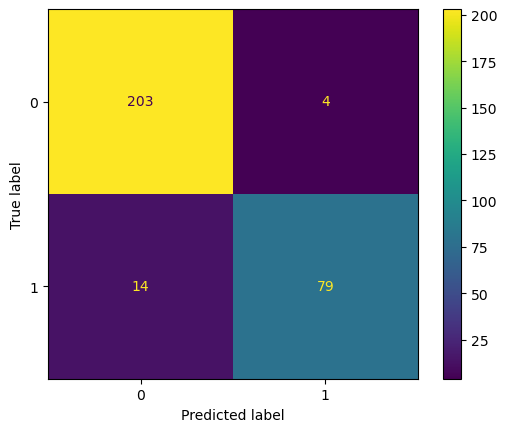

In [65]:
confusion_matrix = metrics.confusion_matrix(test['HiringDecision'], best_forestvals)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1])
cm_display.plot()
plt.show()

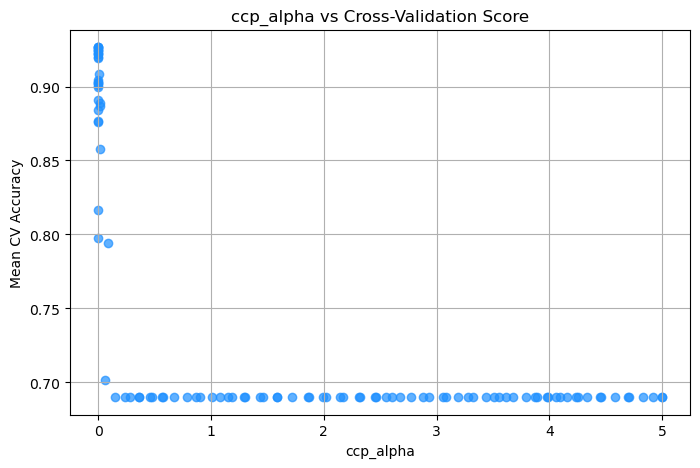

In [67]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame(opt.cv_results_)

plt.figure(figsize=(8, 5))
plt.scatter(results['param_ccp_alpha'].astype(float), results['mean_test_score'], alpha=0.7, color='dodgerblue')
plt.xlabel('ccp_alpha')
plt.ylabel('Mean CV Accuracy')
plt.title('ccp_alpha vs Cross-Validation Score')
plt.grid(True)
plt.show()


In [69]:
results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_ccp_alpha,param_criterion,param_min_samples_leaf,param_min_samples_split,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.126260,0.007677,0.024430,0.000645,0.671250,entropy,14,13,44,"{'ccp_alpha': 0.671249573500204, 'criterion': ...",0.6875,0.6875,0.691667,0.691667,0.691667,0.69,0.002041,31
1,0.677324,0.030827,0.069057,0.007704,2.935706,entropy,3,22,266,"{'ccp_alpha': 2.935705651770781, 'criterion': ...",0.6875,0.6875,0.691667,0.691667,0.691667,0.69,0.002041,31
2,3.441816,0.136544,0.262889,0.002274,2.019584,gini,8,27,1365,"{'ccp_alpha': 2.0195842544770977, 'criterion':...",0.6875,0.6875,0.691667,0.691667,0.691667,0.69,0.002041,31
3,4.226261,0.224123,0.318607,0.022226,0.866636,entropy,4,10,1602,"{'ccp_alpha': 0.8666361224012377, 'criterion':...",0.6875,0.6875,0.691667,0.691667,0.691667,0.69,0.002041,31
4,3.904479,0.236486,0.302353,0.010447,0.360499,entropy,17,29,1557,"{'ccp_alpha': 0.36049902736954137, 'criterion'...",0.6875,0.6875,0.691667,0.691667,0.691667,0.69,0.002041,31


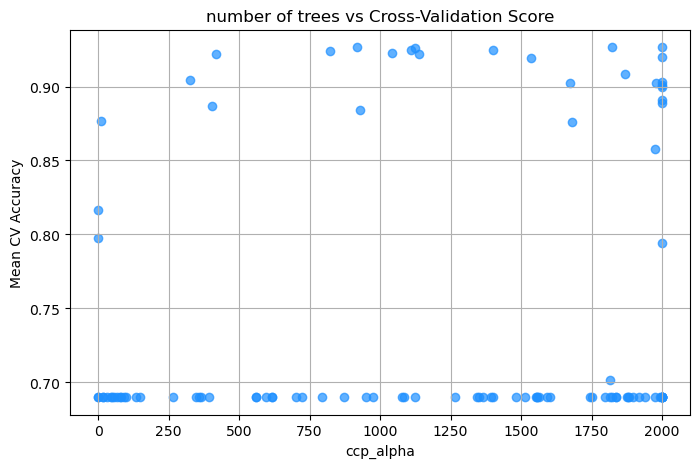

In [71]:
plt.figure(figsize=(8, 5))
plt.scatter(results['param_n_estimators'].astype(float), results['mean_test_score'], alpha=0.7, color='dodgerblue')
plt.xlabel('ccp_alpha')
plt.ylabel('Mean CV Accuracy')
plt.title('number of trees vs Cross-Validation Score')
plt.grid(True)
plt.show()

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

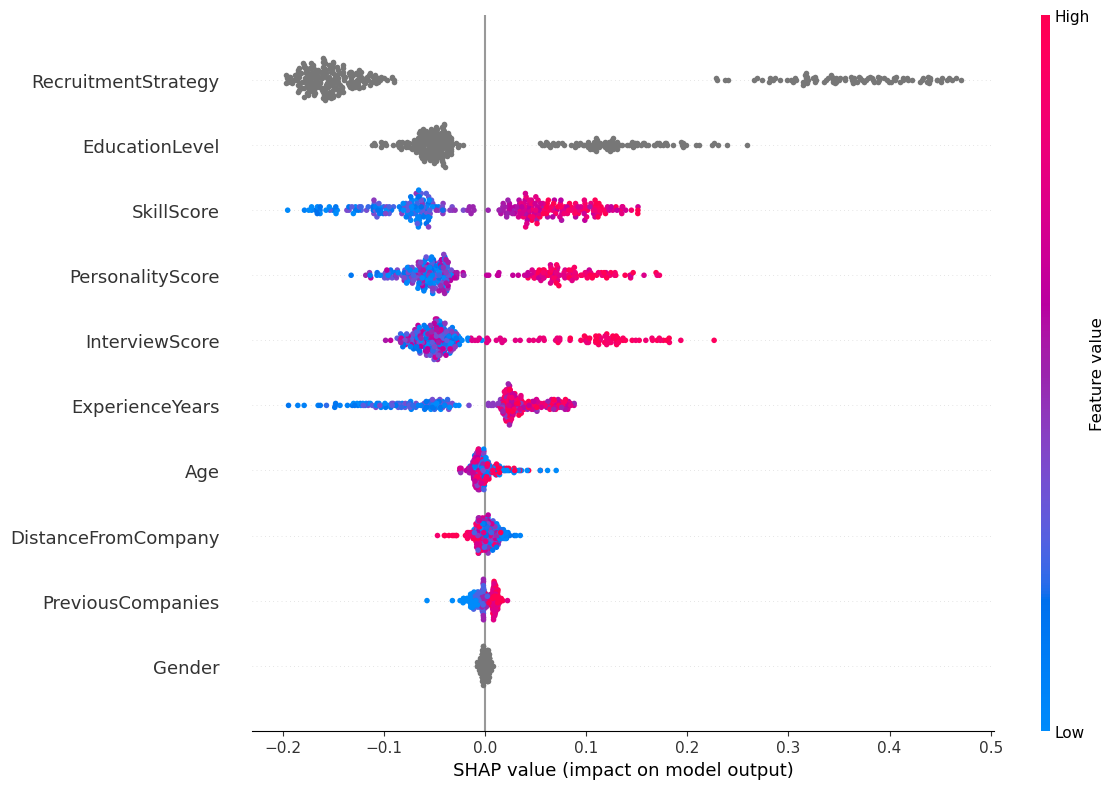

In [94]:
import shap

explainer = shap.TreeExplainer(best_forest)
shap_values = explainer.shap_values(X_test)

shap_values_class1 = shap_values[:, :, 1]
shap.summary_plot(shap_values_class1, X_test, plot_size=(12, 8))


In [90]:
import numpy as np

print(type(shap_values))
if isinstance(shap_values, list):
    print("List length:", len(shap_values))
    print("Shape of shap_values[1]:", np.shape(shap_values[1]))
else:
    print("Shape:", np.shape(shap_values))


<class 'numpy.ndarray'>
Shape: (300, 10, 2)


In [96]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, auc
)

import matplotlib.pyplot as plt

def evaluate_classification_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = model.decision_function(X_test)
    
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
    
    roc_auc = roc_auc_score(y_test, y_proba)
    print(f"ROC AUC: {roc_auc:.4f}")
    
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure(figsize=(6,6))
    plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.4f})')
    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.show()

Confusion Matrix:
[[203   4]
 [ 14  79]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       207
           1       0.95      0.85      0.90        93

    accuracy                           0.94       300
   macro avg       0.94      0.92      0.93       300
weighted avg       0.94      0.94      0.94       300

Accuracy: 0.9400
Precision: 0.9518
Recall: 0.8495
F1 Score: 0.8977
ROC AUC: 0.9287


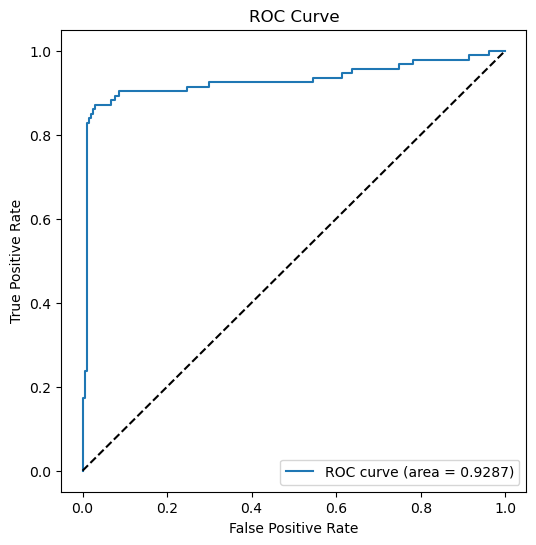

In [100]:
evaluate_classification_model(best_forest, X_test, test['HiringDecision'])

Confusion Matrix:
[[819   9]
 [ 32 340]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       828
           1       0.97      0.91      0.94       372

    accuracy                           0.97      1200
   macro avg       0.97      0.95      0.96      1200
weighted avg       0.97      0.97      0.97      1200

Accuracy: 0.9658
Precision: 0.9742
Recall: 0.9140
F1 Score: 0.9431
ROC AUC: 0.9972


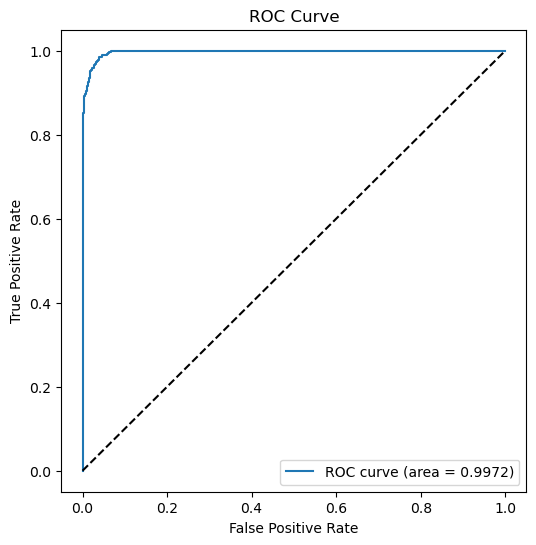

In [102]:
evaluate_classification_model(best_forest, X, y)